# DREAMS Interpolated QSTS Hosting Capacity
This notebook is meant to demonstrate the interpolated hosting capacity
cababilities of DREAMS.

Unlike the Nodal Hosting Capacity function, which looks at a single point
in time and iterates to a hosting capacity value, this interpolated approach
instead uses opendss monitors to collect time series data of interest from
the model, and then interpolate (or extapolate) at each time point an estimate
of the asset size that would cause a hosting capacity threshold to be met.
The smallest result for all time is then selected as a conservative 
hosting capacity value.

To demonstrate this, a small number of buses are selected for analysis over the 
course of three days for both generation and demand hosting capacity.

Then, interpolated results are compared to results created using the 
nodal hosting capacity function at the same point in simulated time.

It should be noted that this method is still experimental and being refined.
Currently, the method is designed to study 3-phase medium voltage buses.

In [1]:
import dreams

from pathlib import Path
import os
import pandas as pd

# Define Paths
Similar to other demos, the feeder used here is the synthetic bay area feeder with a 
single time series demand profile for all loads.

Unlike other DREAMS hosting capacity methods, this exports the collected data
from each bus by default (though this can be turned off).

In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'

output_dir = model_dir / 'temp_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Select Buses to test
This method is designed for 3-phase medium voltage locations.
While the approach is valid for other locations, extra considerations would
have to be accounted for that is beyond the scope of this demo and current 
code base.

In [3]:
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')

In [4]:
buses_to_test = [
    'p1udt888',
    'p1udt222',
    'p1udt16',
    'p1udt333',
    'p1udt440',
    ]

In [5]:
feeder.buses.loc[buses_to_test]

,longitude,latitude,n_phases,phases,kv_base,primary,distance
name,,,,,,,
p1udt888,-122.393607,37.752482,3,123,7.199558,True,0.430128
p1udt222,-122.395315,37.752391,3,123,7.199558,True,0.584205
p1udt16,-122.398544,37.757311,3,123,7.199558,True,1.365715
p1udt333,-122.401206,37.760912,3,123,7.199558,True,1.918593
p1udt440,-122.401268,37.764125,3,123,7.199558,True,2.462179


# Run interpolated generation hosting capacity
The `QSTS_HC` method of the `dreams.hc.interp` code accepts all 
simulation parameters and returns an object that contains results,
execution timings, and other possibly useful data points.

As mentioned before, recorded monitor streams for each bus tested are 
output as netCDF files via the xarray package in the `output_dir` directory.
This is to allow a separation between simulation and calculation of HC
as well as facilitate further method developement.

In [6]:

interp_gen_hc = dreams.hc.interp.QSTS_HC(
    feeder,
    buses_to_test,
    output_dir=output_dir,
    kind='gen',
    step_size_seconds=60*15,  # 15 minute profile
    total_time_steps=24*4*3,  # run for 3 days
    debug=False  # This will produce a 'slightly' more robust output if True
)

** Bus 5/5 


Example of substation demand from openDSS monitor showing 3 days of demand.

Text(0.5, 1.0, 'Feeder Demand')

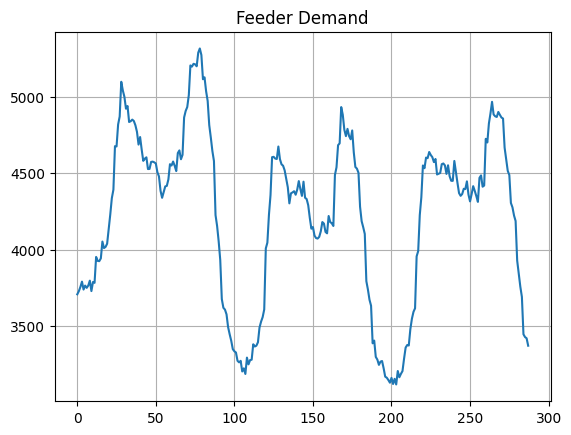

In [7]:
src_df = interp_gen_hc.first_step_monitors['vsource']['source'].df
ax = (src_df['P_total_kW']*-1).plot()
ax.grid()
ax.set_title('Feeder Demand')

Results and timings are compiled into a data frame with various columns of note

In [8]:
interp_gen_hc.result_df.columns

Index(['distance_from_sub', 'qsts_sim_time', 'n_asset_size_tested', 'out_path',
       'dataset_creation_time', 'vchc', 'vchc_ndx', 'vchc_threshold',
       'vchc_element', 'vchc_n_tested_elements', 'tchc', 'tchc_threshold',
       'tchc_element', 'tchc_ndx', 'tchc_n_tested_elements', 'schc',
       'schc_threshold', 'schc_ndx', 'interp_time', 'total_bus_calc_time'],
      dtype='object')

# Run snapshot hosting capacity to validate results

For each interpolated result, the index of the result (or simulated time step),
is used to adjust the initial model state and run the nodal snapshot hosting
capacity method to validate interpolation results.

This is done a bus at a time as the 'critical time step' may be different
for each bus location.

In [9]:
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')

snap_shot_res = []

time_step = 60*15  # 15 minutes per step

for bus_name, row in interp_gen_hc.result_df.iterrows():
    # create times to test from interpolated results
    print(bus_name)
    vchc_t = row['vchc_ndx'] * time_step
    tchc_t = row['tchc_ndx'] * time_step

    bus_res = dreams.hc.NodalSnapshot(
        feeder,
        bus_names=[bus_name],
        constraint='voltage',
        hc_kind='gen',
        mode='duty',
        at_sec=vchc_t,
        save_violations=True
    )

    # generation will typically lead to over voltage violations
    vchc_element = bus_res.violations[bus_name]['over_voltage']['Bus_Name'].values[0]
    bus_res.result_df['voltage_element'] = vchc_element

    thermal_bus_res = dreams.hc.NodalSnapshot(
        feeder,
        bus_names=[bus_name],
        constraint='thermal',
        hc_kind='gen',
        mode='duty',
        at_sec=tchc_t,
        save_violations=True,
    )

    # generation or demand will only trigger over capacity thermal issues
    thermal_element = thermal_bus_res.violations[bus_name]['over_capacity']['Name'].values[0]
    bus_res.result_df['thermal_hc_kw'] = thermal_bus_res.result_df['thermal_hc_kw']
    bus_res.result_df['thermal_element'] = thermal_element

    snap_shot_res.append(bus_res.result_df)

nodal_gen_hc = pd.concat(snap_shot_res)

p1udt888
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.98 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.12 seconds)  
p1udt222
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.66 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 2.88 seconds)  
p1udt16
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 3.00 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.22 seconds)  
p1udt333
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.89 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 2.80 seconds)  
p1udt440
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.69 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.05 seconds)  


# Generation Hosting Capacity result comparison

The interpolated results also calculate substation constrainted hosting 
capacity (SCHC), which in this case, represents a backfeeding situation, 
or when real power delivered from the substation is 0.

In [10]:

nodal_gen_hc[['voltage_hc_kw', 'thermal_hc_kw', 'voltage_element', 'thermal_element',]]

,voltage_hc_kw,thermal_hc_kw,voltage_element,thermal_element
p1udt888,30927,10210,p1udt203-p1udt365x,Line.PADSWITCH(R:P1UDT940-P1UDT941)P1U_9557
p1udt222,24500,8747,p1udt222,Line.L(R:P1UDT222-P1UDT885)
p1udt16,10574,6545,p1udt16,Line.PADSWITCH(R:P1UDT237-P1UDT256)P1U_9370
p1udt333,7649,6092,p1udt333,Line.PADSWITCH(R:P1UDT229-P1UDT342)P1U_9260
p1udt440,6098,3716,p1udt440,Line.PADSWITCH(R:P1UDT158-P1UDT99)P1U_9240


In [11]:
interp_gen_hc.result_df[['vchc','tchc','vchc_element', 'tchc_element', 'schc']]


,vchc,tchc,vchc_element,tchc_element,schc
bus_name,,,,,
p1udt888,31344.607374,11294.630280,p1udt888,padswitch(r:p1udt888-p1udt890)p1u_9550,3116.918649
p1udt222,23886.412906,8886.355828,p1udt222,padswitch(r:p1udt222-p1udt885)p1u_9412,3116.905613
p1udt16,10649.629984,6595.467280,p1udt16,padswitch(r:p1udt251-p1udt252)p1u_9375,3121.026183
p1udt333,7799.716617,6590.283098,p1udt333,padswitch(r:p1udt251-p1udt252)p1u_9375,3127.458066
p1udt440,6255.393103,4496.934667,p1udt440,padswitch(r:p1udt158-p1udt99)p1u_9240,3136.949530


Results show that the interpolation method is reasonably close to the 
nodal results.

It is worth mentioning that the limiting element for either
constraint is not always the same between the two approaches.

#Run Interpolated Demand Hosting Capacity
Deamand, or load hosting capacity is executed in a similar fashion, with
the `kind` parameter now set to `load`.

In [12]:
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')
# best to run with a 'clean' feeder object
interp_load_hc = dreams.hc.interp.QSTS_HC(
    feeder,
    buses_to_test,
    output_dir=output_dir,
    kind='load',
    step_size_seconds=60*15,  # 15 minute profile
    total_time_steps=24*4*3,  # run for 3 days
)

** Bus 5/5 


Again, the nodal snapshot method is used to validate the demand hosting
capacity results.

In [13]:
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')

snap_shot_res = []

time_step = 60*15  # 15 minutes per step

for bus_name, row in interp_load_hc.result_df.iterrows():
    vchc_t = row['vchc_ndx'] * time_step
    tchc_t = row['tchc_ndx']* time_step

    bus_res = dreams.hc.NodalSnapshot(
        feeder,
        bus_names=[bus_name],
        hc_kind='load',
        constraint='voltage',
        mode='duty',
        at_sec=vchc_t,
        save_violations=True
    )

    vchc_element = bus_res.violations[bus_name]['under_voltage']['Bus_Name'].values[0]
    bus_res.result_df['voltage_element'] = vchc_element

    thermal_bus_res = dreams.hc.NodalSnapshot(
        feeder,
        bus_names=[bus_name],
        hc_kind='load',
        constraint='thermal',
        mode='duty',
        at_sec=tchc_t,
        save_violations=True,
    )

    thermal_element = thermal_bus_res.violations[bus_name]['over_capacity']['Name'].values[0]
    bus_res.result_df['thermal_hc_kw'] = thermal_bus_res.result_df['thermal_hc_kw']
    bus_res.result_df['thermal_element'] = thermal_element

    snap_shot_res.append(bus_res.result_df)


Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 3.42 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.39 seconds)  
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.67 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.03 seconds)  
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.84 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.11 seconds)  
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.95 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.06 seconds)  
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 3.02 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.28 seconds)  


## Demand Hosting Capacity result comparison
Again, there is some error involved with the interpolation approach, however,
the TCHC appears to match more closely as the violating element is often
correctly selected.

Substation constraints are not yet incorporated for demand, but such a result
may help identify the maximum amount of load that would cause a substation
limit to be reached, as in, maximum amount of MW the connected substation
is rated for.

In [14]:
nodal_load_hc = pd.concat(snap_shot_res)

nodal_load_hc[['voltage_hc_kw', 'thermal_hc_kw', 'voltage_element', 'thermal_element']]

,voltage_hc_kw,thermal_hc_kw,voltage_element,thermal_element
p1udt888,56528,1694,p1ulv573,Line.L(R:P1UDT1469-P1UHS0_1247)
p1udt222,42153,1244,p1ulv573,Line.PADSWITCH(R:P1UDT885-P1UDT888)P1U_9546
p1udt16,17903,1031,p1ulv573,Line.PADSWITCH(R:P1UDT251-P1UDT252)P1U_9375
p1udt333,13921,1024,p1ulv1083,Line.PADSWITCH(R:P1UDT251-P1UDT252)P1U_9375
p1udt440,11879,1020,p1ulv248,Line.PADSWITCH(R:P1UDT251-P1UDT252)P1U_9375


In [15]:
interp_load_hc.result_df[['vchc', 'tchc', 'vchc_element', 'tchc_element']]

,vchc,tchc,vchc_element,tchc_element
bus_name,,,,
p1udt888,61761.504854,1692.808743,p1ulv573.1.2,l(r:p1udt1469-p1uhs0_1247)
p1udt222,45658.235907,1244.547376,p1ulv573.1.2,padswitch(r:p1udt885-p1udt888)p1u_9546
p1udt16,19017.502598,1030.659314,p1ulv573.1.2,padswitch(r:p1udt251-p1udt252)p1u_9375
p1udt333,14665.822106,1023.564739,p1ulv1083.1.2,padswitch(r:p1udt251-p1udt252)p1u_9375
p1udt440,12659.191484,1019.718902,p1ulv1866.1.2.3,padswitch(r:p1udt251-p1udt252)p1u_9375


# Conclusion
This demo notebook showed how to use the interpolated hosting capacity
functions of DREAMS and validate results using the snapshot hosting 
capacity metho.